# Tarea 7: Clasificación de Texto con Naive Bayes
## Análisis de Sentimiento en Reseñas de Películas

**Nombre:** Verónica Nathaly Alvarado Reyes  
**Fecha:** Viernes 19 de junio del 2026  

### Objetivo:
Familiarizar al estudiante con el algoritmo Naive Bayes para clasificación de texto, aplicando técnicas de preprocesamiento como Bag of Words (CountVectorizer) y TF-IDF, analizando el efecto de hiperparámetros como `alpha` (suavizado Laplaciano) y n-gramas, y evaluando el modelo mediante métricas de precisión, recall y F1-score.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.
6. NO ELIMINAR NINGÚN COMENTARIO

### Descripción del Dataset:
Utilizaremos el dataset **Rotten Tomatoes Movie Reviews** que contiene reseñas de críticos de cine. Cada reseña está clasificada como:
- **fresh**: Reseña positiva
- **rotten**: Reseña negativa

### Archivo requerido:
- `critics.csv` - Dataset de reseñas de películas

## Parte 1: Configuración y Carga de Datos

In [30]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [31]:
# TODO: Cargar el dataset critics.csv
#
# Instrucciones:
# 1. Use pd.read_csv('critics.csv') para cargar el dataset
# 2. Imprima las dimensiones con .shape
# 3. Imprima los nombres de columnas
# 4. Muestre las primeras filas con .head()

# Carga el archivo CSV
critics = pd.read_csv('https://raw.githubusercontent.com/cs109/2015lab10/master/critics.csv')

# Mostrar el número de filas y columnas del dataset
print("Dimensiones:", critics.shape)

# Mostrar los nombres de las columnas
print("\nColumnas:", critics.columns.tolist())

# Mostrar las primeras 5 filas del dataset
critics.head()

Dimensiones: (27631, 8)

Columnas: ['critic', 'fresh', 'imdb', 'publication', 'quote', 'review_date', 'rtid', 'title']


,critic,fresh,imdb,publication,quote,review_date,rtid,title
0,Owen Gleiberman,fresh,114709,Entertainment Weekly,NaN,2011-09-07,9559,Toy story
1,Derek Adams,fresh,114709,Time Out,"So ingenious in concept, design and execution ...",2009-10-04,9559,Toy story
2,Richard Corliss,fresh,114709,TIME Magazine,The year's most inventive comedy.,2008-08-31,9559,Toy story
3,David Ansen,fresh,114709,Newsweek,A winning animated feature that has something ...,2008-08-18,9559,Toy story
4,Leonard Klady,fresh,114709,Variety,The film sports a provocative and appealing st...,2008-06-09,9559,Toy story


In [32]:
# TODO: Limpiar el dataset
#
# Instrucciones:
# 1. Elimine filas con quotes nulos: critics = critics[~critics.quote.isnull()]
# 2. Filtre solo fresh y rotten: critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]
# 3. Imprima las dimensiones después de limpiar

# Elimina las filas donde la columna quote está vacía
critics = critics[~critics.quote.isnull()]

# Conserva solo las críticas clasificadas de fresh o rotten
critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]

# Muestra las nuevas dimensiones ya limpias
print("Dimensiones limpias:", critics.shape)

Dimensiones limpias: (15534, 8)


### Pregunta 1: Tamaño del Dataset
¿Cuántas reseñas válidas quedan después de limpiar el dataset?

A) Aproximadamente 5,000  
B) Aproximadamente 10,000  
C) Aproximadamente 15,000  
D) Aproximadamente 20,000  

**Su Respuesta:** C

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [33]:
# TODO: Explorar estadísticas básicas
#
# Instrucciones:
# 1. Calcule n_reviews = len(critics)
# 2. Calcule n_movies = critics.rtid.nunique()
# 3. Calcule n_critics = critics.critic.nunique()
# 4. Imprima las estadísticas

# Contador de total en las reseñas del dataset
n_reviews = len(critics)

# Revisa cuántas películas únicas hay
n_movies = critics.rtid.nunique()

# Cuenta cuántos críticos únicos hay
n_critics = critics.critic.nunique()

# Muestra los resultados
print(f"Número de las reseñas:  {n_reviews}")
print(f"Número de las películas: {n_movies}")
print(f"Número de los críticos:  {n_critics}")

Número de las reseñas:  15534
Número de las películas: 1921
Número de los críticos:  621


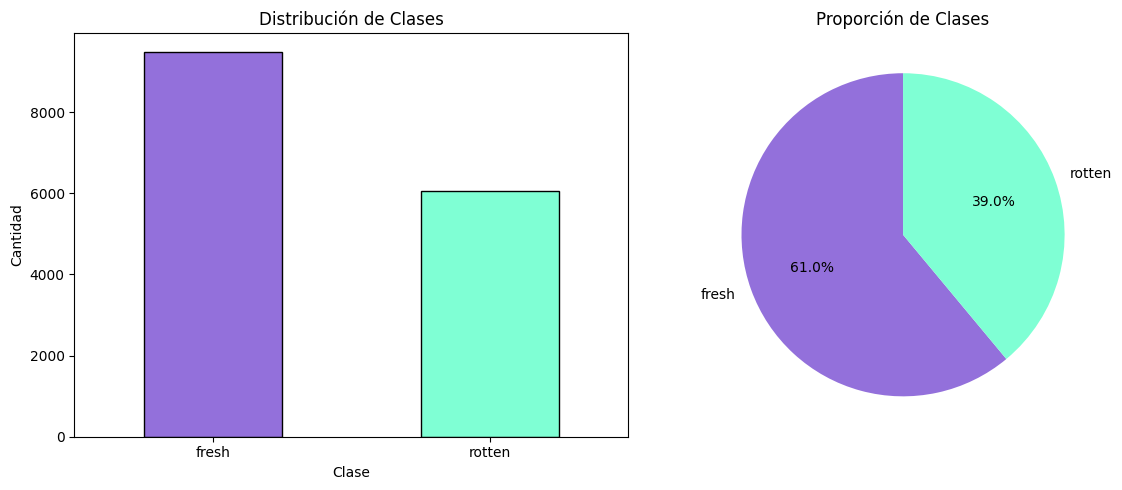


Conteo de las clases:
fresh
fresh     9482
rotten    6052
Name: count, dtype: int64


In [34]:
# TODO: Visualizar distribución de clases
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use critics['fresh'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use .plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas
# 5. Imprima el conteo de clases

# Crear dos gráficos: barras y pastel
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cuentador de cuántas reseñas hay en cada clase
distribucion = critics['fresh'].value_counts()

# Gráfico de barras de la distribución de clases
distribucion.plot(kind='bar', ax=axes[0], color=['mediumpurple', 'aquamarine'], edgecolor='black')
axes[0].set_title('Distribución de Clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de pastel con el porcentaje de cada clase
distribucion.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                  colors=['mediumpurple', 'aquamarine'], startangle=90)
axes[1].set_title('Proporción de Clases')
axes[1].set_ylabel('')

# Se encarga de ajustar el espacio entre los gráficos
plt.tight_layout()
# Muestra el gráfico
plt.show()

# Muestra el conteo de cada clase
print("\nConteo de las clases:")
print(distribucion)

### Pregunta 2: Balance de Clases
¿Cuál es la clase mayoritaria en el dataset?

A) rotten (negativas)  
B) fresh (positivas)  
C) Están perfectamente balanceadas  
D) No se puede determinar  

**Su Respuesta:** B

Estadísticas de longitud (caracteres):
count    15534.000000
mean       117.014484
std         57.581577
min          4.000000
25%         72.000000
50%        114.000000
75%        158.000000
max        256.000000
Name: quote_length, dtype: float64

Estadísticas de número de palabras:
count    15534.000000
mean        19.447534
std          9.792644
min          1.000000
25%         12.000000
50%         19.000000
75%         26.000000
max         49.000000
Name: word_count, dtype: float64


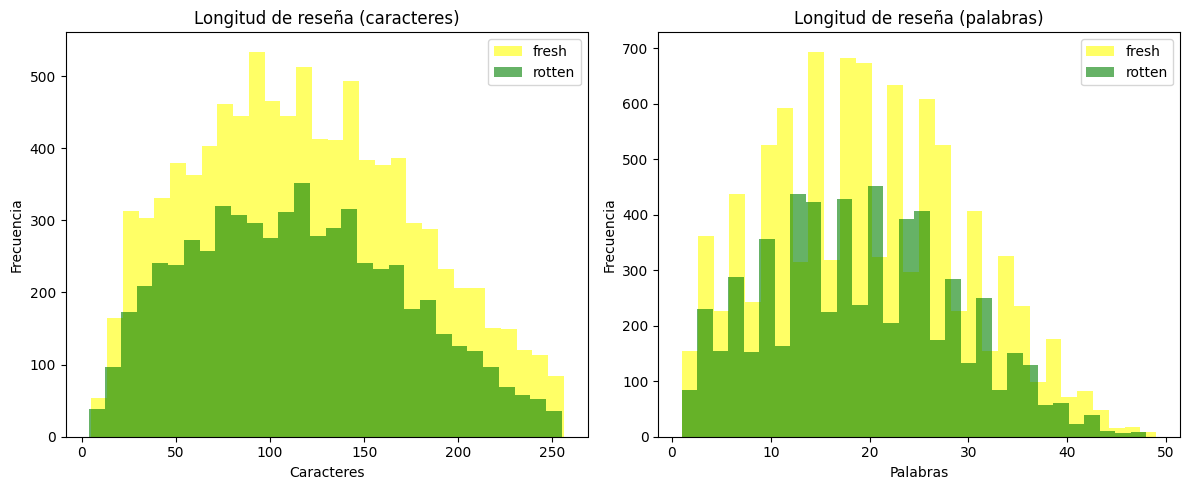

In [35]:
# TODO: Analizar longitud de las reseñas
#
# Instrucciones:
# 1. Cree una columna 'quote_length' con la longitud de cada quote: critics['quote'].apply(len)
# 2. Cree una columna 'word_count' con el número de palabras: critics['quote'].apply(lambda x: len(str(x).split()))
# 3. Imprima estadísticas descriptivas de estas columnas
# 4. Opcional: Cree histogramas comparando fresh vs rotten

# Longitud en caracteres de cada reseña
critics['quote_length'] = critics['quote'].apply(len)

# Número de palabras de cada reseña
critics['word_count'] = critics['quote'].apply(lambda x: len(str(x).split()))

# Estadísticas descriptivas
print("Estadísticas de longitud (caracteres):")
print(critics['quote_length'].describe())
print("\nEstadísticas de número de palabras:")
print(critics['word_count'].describe())

# Histogramas comparando fresh vs rotten
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label, color in zip(['fresh', 'rotten'], ['yellow', 'green']):
    subset = critics[critics['fresh'] == label]
    axes[0].hist(subset['quote_length'], bins=30, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['word_count'], bins=30, alpha=0.6, label=label, color=color)

axes[0].set_title('Longitud de reseña (caracteres)')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].set_title('Longitud de reseña (palabras)')
axes[1].set_xlabel('Palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# TODO: Mostrar ejemplos de reseñas
#
# Instrucciones:
# 1. Imprima 3 ejemplos de reseñas 'fresh' usando critics[critics['fresh']=='fresh']['quote'].head(3)
# 2. Imprima 3 ejemplos de reseñas 'rotten'

print("Ejemplos de reseñas FRESH (positivas):")
for i, quote in enumerate(critics[critics['fresh'] == 'fresh']['quote'].head(3), 1):
    print(f"{i}. {quote}")

print("\nEjemplos de reseñas ROTTEN (negativas):")
for i, quote in enumerate(critics[critics['fresh'] == 'rotten']['quote'].head(3), 1):
    print(f"{i}. {quote}")

Ejemplos de reseñas FRESH (positivas):
1. So ingenious in concept, design and execution that you could watch it on a postage stamp-sized screen and still be engulfed by its charm.
2. The year's most inventive comedy.
3. A winning animated feature that has something for everyone on the age spectrum.

Ejemplos de reseñas ROTTEN (negativas):
1. A gloomy special-effects extravaganza filled with grotesque images, generating fear and despair.
2. Mediocre, regrettably.
3. The movie is too pat and practiced to really be convincing, and the progress of Ariel's relationships with the two grumps seems dictated mostly by the needs of the screenplay.


## Parte 3: Preprocesamiento de Texto - Bag of Words

### Teoría:
El modelo **Bag of Words (BoW)** representa el texto como un vector de frecuencias de palabras, ignorando el orden. **CountVectorizer** de Scikit-Learn implementa este enfoque.

$$\text{Vector} = [\text{count}(w_1), \text{count}(w_2), ..., \text{count}(w_n)]$$

In [37]:
# TODO: Crear una función para preparar los datos
#
# Instrucciones:
# 1. Defina la función make_xy(data, vectorizer) que:
#    a. Aplique vectorizer.fit_transform(data['quote']) para obtener X
#    b. Convierta 'fresh' a binario: y = (data['fresh'] == 'fresh').astype(int).values
#    c. Retorne X, y

def make_xy(data, vectorizer):
    """Prepara los datos para el modelo."""
    # Su código aquí
    # Vectoriza el texto de las reseñas
    X = vectorizer.fit_transform(data['quote'])
    # Convierte la etiqueta 'fresh'/'rotten' a binario (1 = fresh, 0 = rotten)
    y = (data['fresh'] == 'fresh').astype(int).values
    return X, y

In [38]:
# TODO: Aplicar CountVectorizer
#
# Instrucciones:
# 1. Cree vectorizer = CountVectorizer(min_df=5)
# 2. Use make_xy() para obtener X, y
# 3. Imprima la forma de X y y
# 4. Imprima algunos ejemplos de palabras del vocabulario con vectorizer.get_feature_names_out()[:20]

# Vectorizador Bag of Words, ignorando palabras que aparecen en menos de 5 documentos
vectorizer = CountVectorizer(min_df=5)

# Genera la matriz de características X y el vector de etiquetas y
X, y = make_xy(critics, vectorizer)

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

print("\nEjemplo de palabras del vocabulario:")
print(vectorizer.get_feature_names_out()[:20])

Forma de X: (15534, 6166)
Forma de y: (15534,)

Ejemplo de palabras del vocabulario:
['000' '007' '10' '100' '11' '12' '13' '13th' '15' '16' '17' '1930s'
 '1933' '1939' '1940s' '1950s' '1956' '1960s' '1961' '1963']


### Pregunta 3: Dimensiones del Vocabulario
¿Aproximadamente cuántas características (palabras únicas) tiene el vocabulario con min_df=5?

A) 500-1,000  
B) 1,000-5,000  
C) 5,000-10,000  
D) 10,000-20,000  

**Su Respuesta:** C

In [39]:
# TODO: Dividir en train y test
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.3, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
# 4. Imprima la distribución de clases en entrenamiento

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(pd.Series(y_train).value_counts())

Tamaño de X_train: (10873, 6166)
Tamaño de X_test: (4661, 6166)
Tamaño de y_train: (10873,)
Tamaño de y_test: (4661,)

Distribución de clases en entrenamiento:
1    6623
0    4250
Name: count, dtype: int64


## Parte 4: Naive Bayes Multinomial

### Teoría - Teorema de Bayes:
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

**Naive Bayes** asume independencia condicional entre características:
$$P(X|C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_n|C)$$

**Multinomial Naive Bayes** es apropiado para conteos de palabras.

In [40]:
# TODO: Entrenar Multinomial Naive Bayes
#
# Instrucciones:
# 1. Cree el modelo: clf_nb = MultinomialNB()
# 2. Entrene con clf_nb.fit(X_train, y_train)
# 3. Prediga en train y test
# 4. Calcule y muestre las precisiones en train y test con accuracy_score()

clf_nb = MultinomialNB()
clf_nb.fit(X_train, y_train)

y_pred_train = clf_nb.predict(X_train)
y_pred_test = clf_nb.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Precisión en entrenamiento: {train_accuracy:.4f}")
print(f"Precisión en prueba: {test_accuracy:.4f}")

Precisión en entrenamiento: 0.8709
Precisión en prueba: 0.7670


### Pregunta 4: Precisión del Modelo Base
¿Cuál es la precisión aproximada del modelo Naive Bayes en el conjunto de prueba?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 5: Matriz de Confusión y Métricas

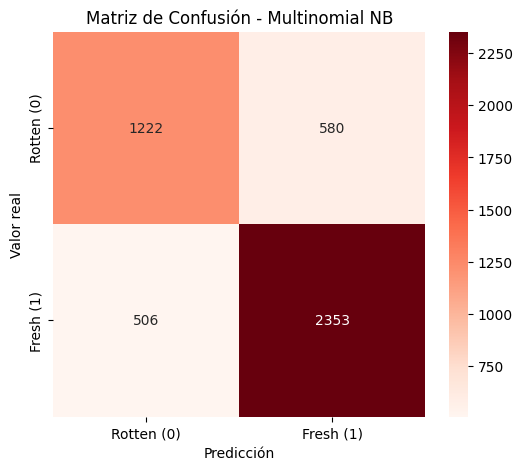

Verdaderos Negativos (TN): 1222
Falsos Positivos (FP):     580
Falsos Negativos (FN):     506
Verdaderos Positivos (TP): 2353


In [41]:
# TODO: Calcular y visualizar la matriz de confusión
#
# Instrucciones:
# 1. Calcule cm = confusion_matrix(y_test, y_pred_test)
# 2. Visualice con sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# 3. Configure xticklabels y yticklabels como ['Rotten (0)', 'Fresh (1)']
# 4. Imprima TN, FP, FN, TP

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Rotten (0)', 'Fresh (1)'],
            yticklabels=['Rotten (0)', 'Fresh (1)'])
plt.title('Matriz de Confusión - Multinomial NB')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP):     {fp}")
print(f"Falsos Negativos (FN):     {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

In [42]:
# TODO: Calcular métricas detalladas
#
# Instrucciones:
# 1. Calcule precision = precision_score(y_test, y_pred_test)
# 2. Calcule recall = recall_score(y_test, y_pred_test)
# 3. Calcule f1 = f1_score(y_test, y_pred_test)
# 4. Imprima las métricas
# 5. Use classification_report() para el reporte completo

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nReporte de clasificación completo:")
print(classification_report(y_test, y_pred_test, target_names=['Rotten', 'Fresh']))

Precision: 0.8023
Recall:    0.8230
F1-score:  0.8125

Reporte de clasificación completo:
              precision    recall  f1-score   support

      Rotten       0.71      0.68      0.69      1802
       Fresh       0.80      0.82      0.81      2859

    accuracy                           0.77      4661
   macro avg       0.75      0.75      0.75      4661
weighted avg       0.77      0.77      0.77      4661



### Pregunta 5: Interpretación de Métricas
Si el modelo tiene alto recall pero baja precisión para la clase 'Fresh', ¿qué significa?

A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas  
B) El modelo no detecta las reseñas positivas  
C) El modelo es perfecto  
D) El modelo solo predice negativas  

**Su Respuesta:** A

## Parte 6: Efecto del Parámetro Alpha (Suavizado Laplaciano)

### Teoría:
El parámetro `alpha` es el **suavizado de Laplace** (additive smoothing). Evita probabilidades de cero para palabras no vistas:

$$P(w|C) = \frac{\text{count}(w,C) + \alpha}{\text{count}(C) + \alpha \cdot |V|}$$

- alpha=1.0: Suavizado estándar (default)
- alpha<1.0: Menos suavizado
- alpha>1.0: Más suavizado

In [43]:
# TODO: Experimentar con diferentes valores de alpha
#
# Instrucciones:
# 1. Defina alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# 2. Para cada alpha:
#    a. Cree MultinomialNB(alpha=alpha)
#    b. Entrene y calcule precisiones train/test
#    c. Calcule precision y recall
# 3. Guarde resultados en un DataFrame e imprima

# Valores de alpha que se van a probar
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

# Lista para guardar los resultados
resultados_alpha = []

# Se prueba el modelo con cada valor de alpha
for alpha in alphas:

    # Crear modelo con el alpha actual
    clf_alpha = MultinomialNB(alpha=alpha)

    # Entrenar el modelo
    clf_alpha.fit(X_train, y_train)

    # Hacer predicciones
    pred_train = clf_alpha.predict(X_train)
    pred_test = clf_alpha.predict(X_test)

    # Calcular métricas principales
    train_acc = accuracy_score(y_train, pred_train)
    test_acc = accuracy_score(y_test, pred_test)
    prec = precision_score(y_test, pred_test)
    rec = recall_score(y_test, pred_test)

    # Guardar resultados
    resultados_alpha.append({
        'alpha': alpha,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'precision': prec,
        'recall': rec
    })

# Convertir resultados en tabla
df_alpha = pd.DataFrame(resultados_alpha)

# Mostrar la tabla
print(df_alpha)

    alpha  train_accuracy  test_accuracy  precision    recall
0   0.001        0.884668       0.751555   0.784925  0.819517
1   0.010        0.884117       0.754988   0.788766  0.820217
2   0.100        0.880898       0.761854   0.797146  0.820567
3   0.500        0.876759       0.764643   0.802126  0.818118
4   1.000        0.870873       0.767003   0.802250  0.823015
5   2.000        0.863975       0.768934   0.796210  0.837705
6   5.000        0.839787       0.755203   0.752945  0.894369
7  10.000        0.766302       0.714010   0.693852  0.955229


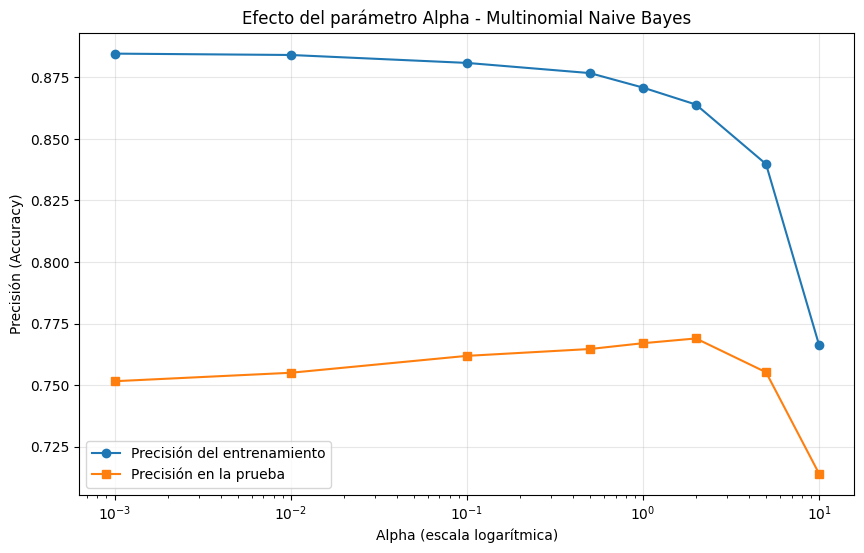

In [44]:
# TODO: Visualizar el efecto de alpha
#
# Instrucciones:
# 1. Grafique train_scores y test_scores vs alphas
# 2. Use plt.xscale('log') para escala logarítmica
# 3. Agregue leyenda, título y etiquetas

# Crea el tamaño de la gráfica
plt.figure(figsize=(10, 6))

# Grafica la precisión del entrenamiento
plt.plot(
    df_alpha['alpha'],
    df_alpha['train_accuracy'],
    marker='o',
    label='Precisión del entrenamiento'
)

# Grafica la precisión de la prueba
plt.plot(
    df_alpha['alpha'],
    df_alpha['test_accuracy'],
    marker='s',
    label='Precisión en la prueba'
)

# Usa escala logarítmica para alpha
plt.xscale('log')

# Etiquetas de los ejes
plt.xlabel('Alpha (escala logarítmica)')
plt.ylabel('Precisión (Accuracy)')

# Título de la gráfica
plt.title('Efecto del parámetro Alpha - Multinomial Naive Bayes')

# Muestra la leyenda
plt.legend()

# Agrega una cuadrícula suave
plt.grid(True, alpha=0.3)

# Muestra la gráfica
plt.show()

### Pregunta 6: Efecto de Alpha
¿Qué ocurre cuando alpha es muy pequeño (ej: 0.001)?

A) El modelo generaliza mejor  
B) El modelo tiende a sobreajustar (train acc >> test acc)  
C) El modelo no aprende nada  
D) No hay efecto significativo  

**Su Respuesta:** B

## Parte 7: N-gramas

### Teoría:
Los **n-gramas** capturan secuencias de n palabras consecutivas:
- Unigrama (1-gram): palabras individuales
- Bigrama (2-gram): pares de palabras
- Trigrama (3-gram): tríos de palabras

Ejemplo: "I love this movie"
- Unigramas: ["I", "love", "this", "movie"]
- Bigramas: ["I love", "love this", "this movie"]

In [45]:
# TODO: Experimentar con diferentes n-gramas
#
# Instrucciones:
# 1. Defina ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
# 2. Para cada configuración:
#    a. Cree CountVectorizer(ngram_range=ngram, min_df=5)
#    b. Use make_xy() para crear X, y
#    c. Divida en train/test
#    d. Entrene MultinomialNB y calcule precisiones
# 3. Imprima los resultados comparativos

# Configuraciones de n-gramas a probar
ngrams_confi = [(1,1), (1,2), (2,2), (1,3), (2,3)]

# Lista para guardar los resultados
resultados_ngrams = []

# Para probar cada configuración de n-gramas
for ngram in ngrams_confi:

    # Crear vectorizador con el n-grama actual
    vec_ngrams = CountVectorizer(
        ngram_range=ngram,
        min_df=5
    )

    # Convertir los textos en matriz numérica
    X_ngram, y_ngram = make_xy(critics, vec_ngram)

    # Dividir datos en entrenamiento y prueba
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_ngram,
        y_ngram,
        test_size=0.3,
        random_state=42
    )

    # Crear el modelo Naive Bayes
    clf_ngrams = MultinomialNB()

    # Entrenar el modelo
    clf_ngrams.fit(X_tr, y_tr)

    # Calcular precisión en entrenamiento
    train_acc = accuracy_score(
        y_tr,
        clf_ngrams.predict(X_tr)
    )

    # Calcular precisión en prueba
    test_acc = accuracy_score(
        y_te,
        clf_ngrams.predict(X_te)
    )

    # Guardar resultados de cada prueba
    resultados_ngrams.append({
        'ngram_range': str(ngram),
        'n_features': X_ngram.shape[1],
        'train_accuracy': train_acc,
        'test_accuracy': test_acc
    })

# Crear tabla con los resultados
df_ngram = pd.DataFrame(resultados_ngram)

# Mostrar resultados
print(df_ngram)

  ngram_range  n_features  train_accuracy  test_accuracy
0      (1, 1)        6166        0.870873       0.767003
1      (1, 2)       13054        0.895613       0.771937
2      (2, 2)        6888        0.822956       0.689552
3      (1, 3)       14727        0.893498       0.765930
4      (2, 3)        8561        0.821025       0.680326


### Pregunta 7: N-gramas
¿Qué ocurre al usar solo bigramas (2,2) en comparación con unigramas (1,1)?

A) Siempre mejora la precisión  
B) Aumenta mucho el número de características y puede sobreajustar  
C) Reduce el número de características  
D) No tiene ningún efecto  

**Su Respuesta:** B

## Parte 8: TF-IDF

### Teoría:
**TF-IDF** (Term Frequency - Inverse Document Frequency) pondera las palabras por su importancia:

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)$$

Donde:
- TF(t,d): Frecuencia del término t en el documento d
- IDF(t): log(N / df(t)) - penaliza palabras muy comunes

In [46]:
# TODO: Aplicar TF-IDF
#
# Instrucciones:
# 1. Cree tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
# 2. Use make_xy() para crear X_tfidf, y_tfidf
# 3. Divida en train/test
# 4. Entrene MultinomialNB
# 5. Calcule y muestre precisiones train/test

# Crear vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    min_df=5,
    stop_words='english'
)

# Convertir textos a matriz TF-IDF
X_tfidf, y_tfidf = make_xy(
    critics,
    tfidf_vectorizer
)

# Dividir datos en entrenamiento y prueba
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y_tfidf,
    test_size=0.3,
    random_state=42
)

# Crear modelo Naive Bayes
clf_tfidf = MultinomialNB()

# Entrenar el modelo con TF-IDF
clf_tfidf.fit(
    X_train_tfidf,
    y_train_tfidf
)

# Calcular precisión en entrenamiento
train_acc_tfidf = accuracy_score(
    y_train_tfidf,
    clf_tfidf.predict(X_train_tfidf)
)

# Calcular precisión en prueba
test_acc_tfidf = accuracy_score(
    y_test_tfidf,
    clf_tfidf.predict(X_test_tfidf)
)

# Mostrar resultados
print(f"Precisión en entrenamiento (TF-IDF): {train_acc_tfidf:.4f}")
print(f"Precisión en prueba (TF-IDF):        {test_acc_tfidf:.4f}")

Precisión en entrenamiento (TF-IDF): 0.8459
Precisión en prueba (TF-IDF):        0.7425


In [47]:
# TODO: Imprimir reporte de clasificación con TF-IDF
#
# Instrucciones:
# 1. Prediga con el modelo TF-IDF
# 2. Use classification_report() para el reporte

# Realizar predicciones con el modelo TF-IDF
y_pred_test_tfidf = clf_tfidf.predict(X_test_tfidf)

# Mostrar el reporte de clasificación
print("Reporte de clasificación (Multinomial NB + TF-IDF):")
# Imprimir métricas por clase
print(classification_report(y_test_tfidf, y_pred_test_tfidf, target_names=['Rotten', 'Fresh']))

Reporte de clasificación (Multinomial NB + TF-IDF):
              precision    recall  f1-score   support

      Rotten       0.79      0.46      0.58      1802
       Fresh       0.73      0.92      0.81      2859

    accuracy                           0.74      4661
   macro avg       0.76      0.69      0.70      4661
weighted avg       0.75      0.74      0.72      4661



### Pregunta 8: TF-IDF vs CountVectorizer
¿Cuál es una ventaja de TF-IDF sobre CountVectorizer simple?

A) Siempre da mejor precisión  
B) Penaliza palabras muy comunes y reduce el sobreajuste  
C) Usa menos memoria  
D) Es más rápido de calcular  

**Su Respuesta:** B

## Parte 9: Interpretación del Modelo

In [48]:
# TODO: Identificar las palabras más predictivas
#
# Instrucciones:
# 1. Obtenga los nombres de características: feature_names = np.array(vectorizer.get_feature_names_out())
# 2. Obtenga log probabilidades: clf_nb.feature_log_prob_[1] (Fresh) y clf_nb.feature_log_prob_[0] (Rotten)
# 3. Calcule la diferencia: log_ratio = log_prob_fresh - log_prob_rotten
# 4. Use argsort() para encontrar las 15 palabras más positivas y negativas
# 5. Imprima las palabras con sus log ratios

# Obtener los nombres de las palabras del vectorizador
feature_names = np.array(vectorizer.get_feature_names_out())

# Probabilidades logarítmicas para cada clase
log_prob_fresh = clf_nb.feature_log_prob_[1]
log_prob_rotten = clf_nb.feature_log_prob_[0]

# Calcular diferencia entre Fresh y Rotten
log_ratio = log_prob_fresh - log_prob_rotten

# Índices de las 15 palabras más asociadas a Fresh
top_positive_idx = np.argsort(log_ratio)[-15:][::-1]

# Índices de las 15 palabras más asociadas a Rotten
top_negative_idx = np.argsort(log_ratio)[:15]

# Mostrar palabras más relacionadas con reseñas positivas
print("Las 15 palabras más asociadas a FRESH (positivas):")

for idx in top_positive_idx:
    print(f"{feature_names[idx]:20s}  log_ratio = {log_ratio[idx]:.4f}")

# Mostrar palabras más relacionadas con reseñas negativas
print("\nLas 15 palabras más asociadas a ROTTEN (negativas):")

for idx in top_negative_idx:
    print(f"{feature_names[idx]:20s}  log_ratio = {log_ratio[idx]:.4f}")

Las 15 palabras más asociadas a FRESH (positivas):
delight               log_ratio = 3.1463
superb                log_ratio = 2.8950
richly                log_ratio = 2.6073
bold                  log_ratio = 2.6073
captures              log_ratio = 2.5585
rousing               log_ratio = 2.5072
gentle                log_ratio = 2.5072
innocence             log_ratio = 2.5072
winning               log_ratio = 2.4531
intimate              log_ratio = 2.4531
touching              log_ratio = 2.3560
irresistible          log_ratio = 2.3354
kurosawa              log_ratio = 2.3354
myth                  log_ratio = 2.3354
childhood             log_ratio = 2.2708

Las 15 palabras más asociadas a ROTTEN (negativas):
lame                  log_ratio = -3.5283
pointless             log_ratio = -3.3817
uninspired            log_ratio = -3.2704
unfortunately         log_ratio = -3.2098
unfunny               log_ratio = -2.8351
witless               log_ratio = -2.8351
charmless             log_rat

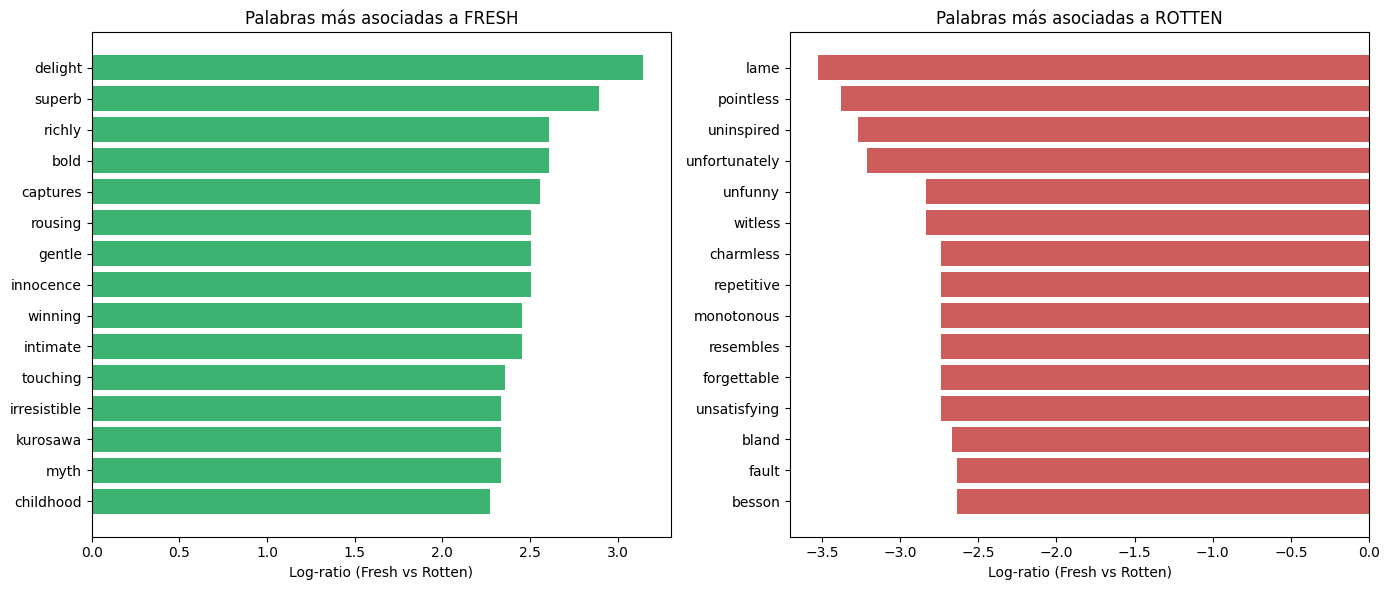

In [49]:
# TODO: Visualizar las palabras más predictivas
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, grafique las palabras más positivas con barh()
# 3. En el segundo subplot, grafique las palabras más negativas
# 4. Agregue títulos y etiquetas

# Crear dos gráficos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Obtener palabras y valores más asociados a Fresh
pos_words = feature_names[top_positive_idx]
pos_values = log_ratio[top_positive_idx]

# Graficar palabras positivas
axes[0].barh(
    pos_words[::-1],
    pos_values[::-1],
    color='mediumseagreen'
)

# Personalizar gráfico de Fresh
axes[0].set_title('Palabras más asociadas a FRESH')
axes[0].set_xlabel('Log-ratio (Fresh vs Rotten)')

# Obtener palabras y valores más asociados a Rotten
neg_words = feature_names[top_negative_idx]
neg_values = log_ratio[top_negative_idx]

# Graficar palabras negativas
axes[1].barh(
    neg_words[::-1],
    neg_values[::-1],
    color='indianred'
)

# Personalizar gráfico de Rotten
axes[1].set_title('Palabras más asociadas a ROTTEN')
axes[1].set_xlabel('Log-ratio (Fresh vs Rotten)')

# Ajustar espacios entre gráficos
plt.tight_layout()

# Mostrar la figura final
plt.show()

### Pregunta 9: Interpretabilidad
¿Qué tipo de palabras esperaría encontrar asociadas a reseñas negativas?

A) Palabras como "excellent", "amazing", "brilliant"  
B) Palabras como "boring", "bad", "disappointing"  
C) Palabras neutrales como "the", "and", "is"  
D) Nombres de actores  

**Su Respuesta:** B

## Parte 10: Predicción con Nuevas Reseñas

In [50]:
# TODO: Probar el modelo con nuevas reseñas
#
# Instrucciones:
# 1. Defina una lista de nuevas reseñas de ejemplo
# 2. Transforme con vectorizer.transform(new_reviews)
# 3. Prediga con clf_nb.predict()
# 4. Obtenga probabilidades con clf_nb.predict_proba()
# 5. Imprima cada reseña con su predicción y probabilidades

new_reviews = [
    "This movie is absolutely amazing! Best film of the year!",
    "Terrible waste of time. Boring and predictable.",
    "A decent film with good performances but weak plot.",
    "Masterpiece! Incredible acting and stunning visuals.",
    "I've seen better. Nothing special about this one."
]

# Su código aquí
# Convertir nuevas reseñas a formato numérico
new_reviews_vec = vectorizer.transform(new_reviews)

# Predecir la clase de cada reseña
predictions = clf_nb.predict(new_reviews_vec)

# Obtener probabilidades de cada clase
probabilities = clf_nb.predict_proba(new_reviews_vec)

# Mostrar resultados de cada reseña
for review, pred, proba in zip(new_reviews, predictions, probabilities):

    # Asignar etiqueta según la predicción
    label = 'FRESH' if pred == 1 else 'ROTTEN'

    # Mostrar la reseña original
    print(f"Reseña: {review}")

    # Mostrar si fue clasificada como positiva o negativa
    print(f"Predicción: {label}")

    # Mostrar probabilidades para Rotten y Fresh
    print(f"Probabilidades [Rotten, Fresh]: [{proba[0]:.4f}, {proba[1]:.4f}]")

    # Separador visual
    print("-" * 60)

Reseña: This movie is absolutely amazing! Best film of the year!
Predicción: FRESH
Probabilidades [Rotten, Fresh]: [0.0249, 0.9751]
------------------------------------------------------------
Reseña: Terrible waste of time. Boring and predictable.
Predicción: ROTTEN
Probabilidades [Rotten, Fresh]: [0.9848, 0.0152]
------------------------------------------------------------
Reseña: A decent film with good performances but weak plot.
Predicción: FRESH
Probabilidades [Rotten, Fresh]: [0.4524, 0.5476]
------------------------------------------------------------
Reseña: Masterpiece! Incredible acting and stunning visuals.
Predicción: FRESH
Probabilidades [Rotten, Fresh]: [0.0049, 0.9951]
------------------------------------------------------------
Reseña: I've seen better. Nothing special about this one.
Predicción: ROTTEN
Probabilidades [Rotten, Fresh]: [0.6573, 0.3427]
------------------------------------------------------------


In [51]:
# TODO: Identificar las palabras más predictivas
#
# Instrucciones:
# 1. Obtenga los nombres de características: feature_names = np.array(vectorizer.get_feature_names_out())
# 2. Obtenga log probabilidades: clf_nb.feature_log_prob_[1] (Fresh) y clf_nb.feature_log_prob_[0] (Rotten)
# 3. Calcule la diferencia: log_ratio = log_prob_fresh - log_prob_rotten
# 4. Use argsort() para encontrar las 15 palabras más positivas y negativas
# 5. Imprima las palabras con sus log ratios

# Obtener los nombres de las palabras del vectorizador
feature_names = np.array(vectorizer.get_feature_names_out())

# Probabilidades logarítmicas para cada clase
log_prob_fresh = clf_nb.feature_log_prob_[1]
log_prob_rotten = clf_nb.feature_log_prob_[0]

# Calcular diferencia entre Fresh y Rotten
log_ratio = log_prob_fresh - log_prob_rotten

# Índices de las 15 palabras más asociadas a Fresh
top_positive_idx = np.argsort(log_ratio)[-15:][::-1]

# Índices de las 15 palabras más asociadas a Rotten
top_negative_idx = np.argsort(log_ratio)[:15]

# Mostrar palabras más relacionadas con reseñas positivas
print("Las 15 palabras más asociadas a FRESH (positivas):")

for idx in top_positive_idx:
    print(f"{feature_names[idx]:20s}  log_ratio = {log_ratio[idx]:.4f}")

# Mostrar palabras más relacionadas con reseñas negativas
print("\nLas 15 palabras más asociadas a ROTTEN (negativas):")

for idx in top_negative_idx:
    print(f"{feature_names[idx]:20s}  log_ratio = {log_ratio[idx]:.4f}")

Las 15 palabras más asociadas a FRESH (positivas):
delight               log_ratio = 3.1463
superb                log_ratio = 2.8950
richly                log_ratio = 2.6073
bold                  log_ratio = 2.6073
captures              log_ratio = 2.5585
rousing               log_ratio = 2.5072
gentle                log_ratio = 2.5072
innocence             log_ratio = 2.5072
winning               log_ratio = 2.4531
intimate              log_ratio = 2.4531
touching              log_ratio = 2.3560
irresistible          log_ratio = 2.3354
kurosawa              log_ratio = 2.3354
myth                  log_ratio = 2.3354
childhood             log_ratio = 2.2708

Las 15 palabras más asociadas a ROTTEN (negativas):
lame                  log_ratio = -3.5283
pointless             log_ratio = -3.3817
uninspired            log_ratio = -3.2704
unfortunately         log_ratio = -3.2098
unfunny               log_ratio = -2.8351
witless               log_ratio = -2.8351
charmless             log_rat

### Pregunta 10: Predicciones
¿Qué método se usa para obtener las probabilidades de cada clase?

A) predict()  
B) predict_proba()  
C) score()  
D) fit()  

**Su Respuesta:** B

## Parte 11: Comparación de Modelos

In [52]:
# TODO: Comparar Multinomial vs Bernoulli Naive Bayes
#
# Instrucciones:
# 1. Cree y entrene BernoulliNB() con los mismos datos
# 2. Calcule precisiones train/test
# 3. Cree un DataFrame comparando:
#    - Multinomial NB
#    - Bernoulli NB
#    - Multinomial + TF-IDF
# 4. Imprima la tabla comparativa

clf_bnb = BernoulliNB()
clf_bnb.fit(X_train, y_train)

train_acc_bnb = accuracy_score(y_train, clf_bnb.predict(X_train))
test_acc_bnb = accuracy_score(y_test, clf_bnb.predict(X_test))

comparacion = pd.DataFrame({
    'Modelo': ['Multinomial NB', 'Bernoulli NB', 'Multinomial NB + TF-IDF'],
    'Train Accuracy': [train_accuracy, train_acc_bnb, train_acc_tfidf],
    'Test Accuracy': [test_accuracy, test_acc_bnb, test_acc_tfidf]
})

print(comparacion)

                    Modelo  Train Accuracy  Test Accuracy
0           Multinomial NB        0.870873       0.767003
1             Bernoulli NB        0.870229       0.769577
2  Multinomial NB + TF-IDF        0.845857       0.742545


### Pregunta 11: Multinomial vs Bernoulli
¿Cuál es la diferencia principal entre Multinomial y Bernoulli Naive Bayes?

A) No hay diferencia  
B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria  
C) Bernoulli es siempre mejor  
D) Multinomial solo funciona con TF-IDF  

**Su Respuesta:** B

### Pregunta 12: Suposición de Naive Bayes
¿Cuál es la suposición principal del algoritmo Naive Bayes?

A) Las características tienen distribución normal  
B) Las características son independientes dada la clase  
C) Los datos deben estar normalizados  
D) Debe haber balance de clases  

**Su Respuesta:** B

### Pregunta 13: Ventajas de Naive Bayes
¿Cuál es una ventaja de Naive Bayes para clasificación de texto?

A) Siempre da la mejor precisión  
B) Es rápido de entrenar y funciona bien con alta dimensionalidad  
C) No requiere preprocesamiento  
D) Captura relaciones complejas entre palabras  

**Su Respuesta:** B

### Pregunta 14: Stop Words
¿Qué son las "stop words" en procesamiento de texto?

A) Palabras con errores ortográficos  
B) Palabras muy comunes que aportan poca información (the, is, and)  
C) Palabras negativas  
D) Palabras técnicas  

**Su Respuesta:** B

### Pregunta 15: min_df en CountVectorizer
¿Qué hace el parámetro min_df=5 en CountVectorizer?

A) Limita a 5 palabras por documento  
B) Ignora palabras que aparecen en menos de 5 documentos  
C) Usa solo las 5 palabras más frecuentes  
D) Divide los datos en 5 partes  

**Su Respuesta:** B

## ¡Excelente Trabajo!

Responda las preguntas basadas en sus ejecuciones. Entregue el notebook completado con todas las celdas ejecutadas.